# Synthetic pretraining: populations, learning curves and transfer to real data

What did every variant see during synthetic pretraining, did the synthetic phases converge, and how large is the gap between the synthetic validation loss and the real test loss of the pretrained model?

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

Recorded validation and test values come from the trainer's data loaders, which re-sample the partition with
the phase's supervision sampling (positive : unlabelled = 1 : 1, with replacement); they are estimates on a
class-balanced re-sample, not plain partition means (part 0_03).

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "synthetic_pretraining_curves"
AXIS = None
STAGE = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]

curves = table('curves')
group_curves = table('group_curves')
populations = table('variant_populations')
## Epochs restart in every phase; the offset of a phase is the number of epochs of the phases before it
populations = populations.sort_values(['axis', 'variant', 'phase_index'])
populations['offset'] = populations.groupby(['axis', 'variant']).epochs.cumsum() - populations.epochs
group_curves = group_curves.merge(populations[['axis', 'variant', 'phase_index', 'offset']], on=['axis', 'variant', 'phase_index'])
group_curves['step'] = group_curves.offset + group_curves.epoch

Analysis: synthetic_pretraining_curves | axis: None | stage: None | models: 310
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}


## Producing the tables this notebook reads

### Methodology

#### Implementation

`synthetic_pretraining_curves` reads the training histories of the pretrained models (synthetic phases and
the zero-epoch real test) and of the baselines, the phase configuration of every pretraining task, and the
token exposure of the regenerated synthetic artifacts (`synthetic_reference` level: the artifacts are
rebuilt locally from the campaign configuration by the runtime's own builder and checked against the
generator statistics).

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis synthetic_pretraining_curves > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Synthetic populations and token exposure

### Methodology

#### Theoretical

Every permutation population compiles a token bag: 30 tokens per eligible class and per blank bin (base),
plus 30 overlap-bonus tokens per class that shares a bin with another class in a training pixel, plus 30
rare-bonus tokens per class of the least-annotated quarter. Only classes with a theoretical isotope
envelope are generator-eligible. The single-bin population (`axis`) has ten spectra per bin.

#### Implementation

`variant_populations` (phase, population and epochs per variant) and `exposure` (tokens and rows per
population, class and token kind; blank tokens carry no class and are not listed).

#### Figure descriptions

No figure. First table: populations and epochs of every variant per phase. Second: total class tokens per
population and kind; third: number of classes with at least one token of a kind.

In [3]:
display(populations.pivot_table(index='variant', columns=['axis', 'phase_index'], values='population', aggfunc='first').reindex(VARIANTS))
exposure = table('exposure')
display(exposure.pivot_table(index=['axis', 'population'], columns='kind', values='tokens', aggfunc='sum', fill_value=0))
display(exposure.pivot_table(index=['axis', 'population'], columns='kind', values='class_index', aggfunc='nunique', fill_value=0))

axis                  axis-100-3000                           axis-200-900                     
phase_index                       0                    1                 0                    1
variant                                                                                        
P0_single                      axis                  NaN              axis                  NaN
P1_permutation     permutation_base                  NaN  permutation_base                  NaN
P2_joint_base            joint_base                  NaN        joint_base                  NaN
P2_staged_base                 axis     permutation_base              axis     permutation_base
P3_joint_overlap      joint_overlap                  NaN     joint_overlap                  NaN
P3_staged_overlap              axis  permutation_overlap              axis  permutation_overlap
P4_joint_rare            joint_rare                  NaN        joint_rare                  NaN
P4_staged_rare                 axis     permutation_rare              axis     permutation_rare
P5_joint_all              joint_all                  NaN         joint_all                  NaN
P5_staged_all                  axis      permutation_all              axis      permutation_all

kind                               base_class  overlap_bonus  rare_bonus  single
axis          population                                                        
axis-100-3000 axis                          0              0           0    1030
              joint_all                  3090            240         780    1030
              joint_base                 3090              0           0    1030
              joint_overlap              3090            240           0    1030
              joint_rare                 3090              0         780    1030
              permutation_all            3090            240         780       0
              permutation_base           3090              0           0       0
              permutation_overlap        3090            240           0       0
              permutation_rare           3090              0         780       0
axis-200-900  axis                          0              0           0     970
              joint_all                  2910            240         750     970
              joint_base                 2910              0           0     970
              joint_overlap              2910            240           0     970
              joint_rare                 2910              0         750     970
              permutation_all            2910            240         750       0
              permutation_base           2910              0           0       0
              permutation_overlap        2910            240           0       0
              permutation_rare           2910              0         750       0

kind                               base_class  overlap_bonus  rare_bonus  single
axis          population                                                        
axis-100-3000 axis                          0              0           0     103
              joint_all                   103              8          26     103
              joint_base                  103              0           0     103
              joint_overlap               103              8           0     103
              joint_rare                  103              0          26     103
              permutation_all             103              8          26       0
              permutation_base            103              0           0       0
              permutation_overlap         103              8           0       0
              permutation_rare            103              0          26       0
axis-200-900  axis                          0              0           0      97
              joint_all                    97              8          25      97
              joint_base                   97              0           0      97
              joint_overlap                97              8           0      97
              joint_rare                   97              0          25      97
              permutation_all              97              8          25       0
              permutation_base             97              0           0       0
              permutation_overlap          97              8           0       0
              permutation_rare             97              0          25       0

### Remarks

- Only 97 (200-900) and 103 (100-3000) of the head classes are generator-eligible; every other head class never appears in the synthetic data, so the synthetic head learns nothing about it.
- Per permutation population the class tokens are 30 per eligible class (2910 / 3090), plus 240 overlap-bonus tokens (8 classes) and 750 / 780 rare-bonus tokens (25 / 26 classes). The overlap quota therefore touches 8 % of the eligible classes and adds 8 % tokens; the rare quota touches a quarter and adds 26 %.

### Notes

## Synthetic learning curves

### Methodology

#### Theoretical

Masserstein and BCE losses of the synthetic phases, training and validation (the validation split of the
synthetic artifact). Staged variants show two consecutive phases (single bins, then permutations); the
step axis concatenates them.

#### Implementation

`group_curves`: mean, minimum and maximum over the five repetitions per variant, phase, component, split
and epoch; `step` = epochs of the previous phases + epoch.

#### Figure descriptions

Rows = components (Masserstein, BCE, total loss), columns = axes; one line per variant (validation), band =
min-max over repetitions; log y axis.

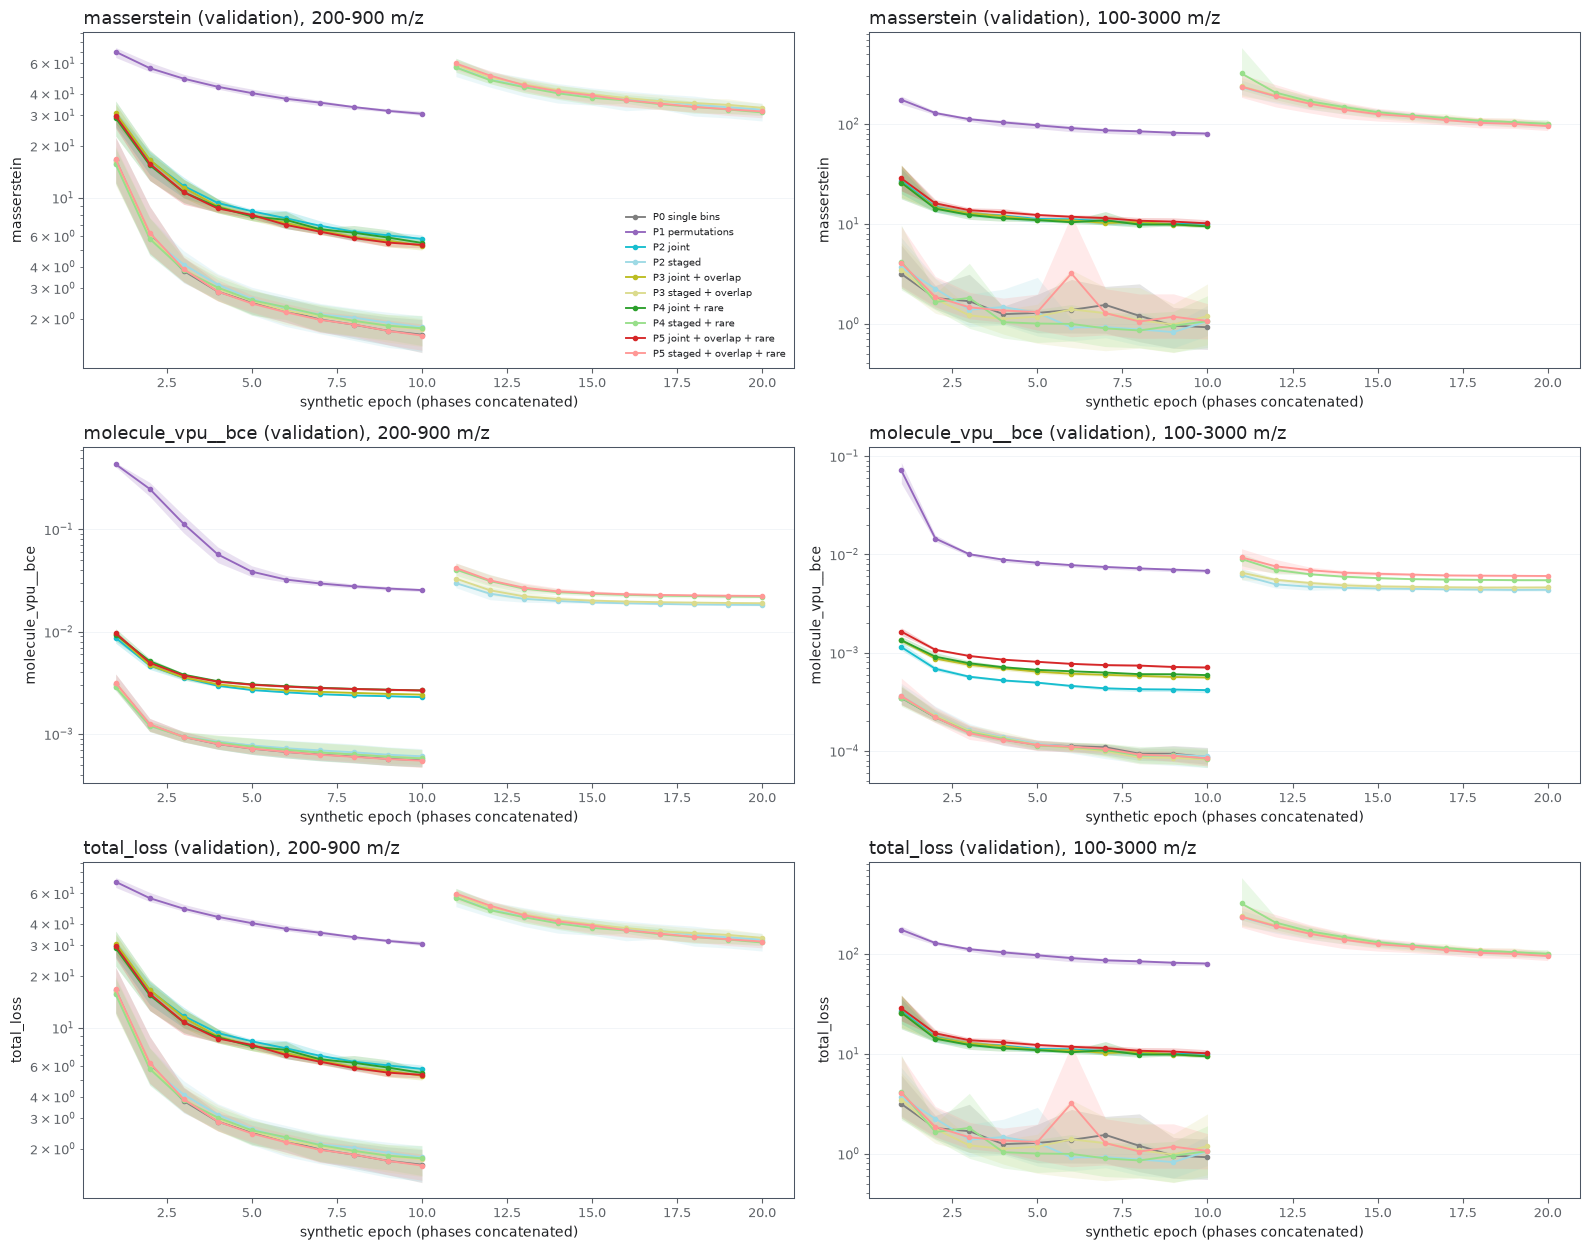

In [4]:
components = ['masserstein', 'molecule_vpu__bce', 'total_loss']
figure, axes = plt.subplots(len(components), len(AXES), figsize=(8 * len(AXES), 4.2 * len(components)), dpi=theme.figure_dpi)
for row, component in enumerate(components):
    for column, axis in enumerate(AXES):
        rows = group_curves[(group_curves.axis == axis) & (group_curves.component == component) & (group_curves.split == 'validation')]
        for variant, frame in rows.groupby('variant'):
            ## A staged variant draws each phase as its own segment
            for _, phase in frame.groupby('phase_index'):
                figures.epoch_curves(phase, levels=[variant], labels=VARIANT_LABELS, colors=VARIANT_COLORS, x='step', low='min',
                                     high='max', log_y=True, xlabel='synthetic epoch (phases concatenated)', ylabel=component,
                                     title=f'{component} (validation), {AXIS_LABELS[axis]}', ax=axes[row, column], theme=theme)
        if (row, column) == (0, 0):
            handles, names = axes[row, column].get_legend_handles_labels()
            unique = dict(zip(names, handles))
            axes[row, column].legend(unique.values(), unique.keys(), frameon=False, fontsize=7)
        else:
            axes[row, column].get_legend().remove()
figure.tight_layout()

### Remarks

- Every synthetic phase decreases smoothly without divergence (narrow min-max bands, one transient spike of P5 staged in the 100-3000 single-bin phase); the losses are still decreasing slowly at the end of each phase. The single-bin population reaches a validation W1 of about 1-2, the joint populations about 5-10, the permutation phases about 30 (200-900) and 80-100 (100-3000): mixed permutation spectra are much harder to reconstruct than single-bin spectra.
- The staged permutation phase starts from the single-bin model but begins no lower than P1 at its first epoch (about 60 against 68 on 200-900, 230-320 against 170 on 100-3000), i.e. the single-bin phase gives no head start on permutation spectra.

### Notes

## Synthetic validation loss against the real test loss

### Methodology

#### Theoretical

        The final synthetic validation $W_1$ (end of the last synthetic phase) is compared with the $W_1$ of the same
        model on the real test pixels without any real training. The ratio real / synthetic measures the domain gap:
        a model that fits the synthetic spectra well but reconstructs real spectra badly has a large ratio.

Recorded validation and test values come from the trainer's data loaders, which re-sample the partition with
the phase's supervision sampling (positive : unlabelled = 1 : 1, with replacement); they are estimates on a
class-balanced re-sample, not plain partition means (part 0_03).

#### Implementation

`synthetic_real_gap` (one row per pretrained model).

#### Figure descriptions

Scatter per axis: x = synthetic validation $W_1$, y = real test $W_1$ (both log), colour = variant. Table:
mean ratio per variant and axis.

axis,axis-100-3000,axis-200-900
variant,,
P0_single,357.1,125.7
P1_permutation,2.0,1.5
P2_joint_base,22.1,8.6
P2_staged_base,2.5,1.4
P3_joint_overlap,21.5,10.0
P3_staged_overlap,2.5,1.5
P4_joint_rare,24.5,9.7
P4_staged_rare,2.4,1.6
P5_joint_all,21.6,10.4


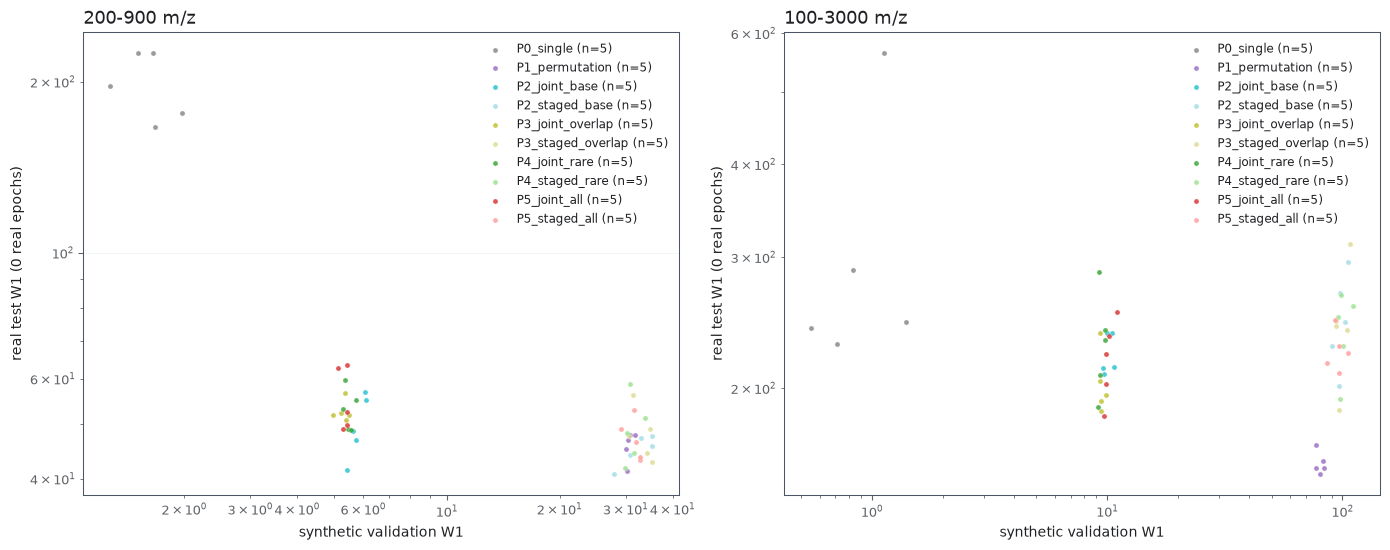

In [5]:
gap = table('synthetic_real_gap')
figure, axes = plt.subplots(1, len(AXES), figsize=(7 * len(AXES), 5.6), dpi=theme.figure_dpi)
for ax, axis in zip(axes, AXES):
    figures.paired_scatter(gap[gap.axis == axis], x='synthetic_validation', y='real_test', hue='variant', hue_order=VARIANTS,
                           colors=VARIANT_COLORS, xlabel='synthetic validation W1', ylabel='real test W1 (0 real epochs)',
                           title=AXIS_LABELS[axis], diagonal=False, log=True, ax=ax, theme=theme)
figure.tight_layout()
display(gap.groupby(['variant', 'axis']).real_over_synthetic.mean().unstack().reindex(VARIANTS).round(1))

### Remarks

- axis-200-900: real / synthetic W1 ratio 1.4-1.6 for P1 and the staged variants, 8.6-10 for the joint variants and 126 for P0.
- axis-100-3000: real / synthetic W1 ratio 2-2.5 for P1 and the staged variants, 22-24 for the joint variants and 357 for P0.

### Notes

## Real test losses of the pretrained models and of the baselines

### Methodology

#### Theoretical

        The zero-epoch real test (`pretrain_only_real_test`) evaluates the pretrained model with the real-data
        objective (Masserstein, VPU, contractive, peak permutation) on the real test partition; the baselines' test
        values come from their final real evaluation. This is the starting point of both fine-tuning stages.

Recorded validation and test values come from the trainer's data loaders, which re-sample the partition with
the phase's supervision sampling (positive : unlabelled = 1 : 1, with replacement); they are estimates on a
class-balanced re-sample, not plain partition means (part 0_03).

#### Implementation

`real_test` (test split of the histories).

#### Figure descriptions

No figure; repetition means per variant, component and axis.

In [6]:
real = table('real_test')
display(real.groupby(['variant', 'axis', 'component']).value.mean().unstack(['axis', 'component']).reindex(ORDER).round(3))

axis              axis-100-3000                                                           axis-200-900                                                          
component           contractive masserstein molecule_vpu__vpu peak_permutation total_loss  contractive masserstein molecule_vpu__vpu peak_permutation total_loss
variant                                                                                                                                                         
baseline                 17.914       4.148            -2.561            0.379      3.672       22.270       3.354            -2.543            0.386      2.890
P0_single                92.506     313.809             0.696            3.492    314.137      333.742     197.650             0.363            3.159    198.393
P1_permutation            4.785     158.696             0.019            3.935    158.713       50.662      45.746             0.068            3.536     45.865
P2_joint_base             4.512     222.040             0.175            3.945    222.088       39.451      49.762             0.184            3.512     49.881
P2_staged_base            9.804     247.660             0.172            3.868    247.718       46.146      45.023             0.190            3.486     45.157
P3_joint_overlap          4.291     203.245             0.169            3.918    203.291       46.823      52.680             0.143            3.553     52.806
P3_staged_overlap        10.474     245.506             0.165            3.830    245.563       54.069      47.959             0.273            3.536     48.125
P4_joint_rare             4.343     231.077             0.149            3.860    231.119       42.084      53.068             0.134            3.506     53.182
P4_staged_rare           11.104     239.007             0.177            3.897    239.069       47.633      48.804             0.151            3.576     48.933
P5_joint_all              4.575     219.425             0.163            3.930    219.471       44.334      55.441             0.163            3.554     55.566
P5_staged_all             8.946     224.795             0.206            3.740    224.858       45.030      46.991             0.218            3.581     47.128

### Remarks

- axis-200-900: real test W1 at 0 real epochs 45-55.4 (P1-P5), 198 (P0), against 3.35 for the trained baseline.
- axis-100-3000: real test W1 at 0 real epochs 159-248 (P1-P5), 314 (P0), against 4.15 for the trained baseline.

### Notes

## Results / Summary

### LLM

- **Observed:** the synthetic phases train smoothly, but none of them transfers to real spectra without real training: real test W1 at 0 real epochs is 45-55 (200-900) and 159-248 (100-3000) for P1-P5 against 3.4 / 4.1 for the baselines; P0 (single bins only) is worst (198 / 314).
- **Observed:** P1 and the staged variants have a real / synthetic W1 ratio of about 1.4-2.5 because their last synthetic phase is already hard (mixed spectra); the joint variants look good on their (easier, single-bin rich) synthetic validation and have ratios of 9-25.
- **Interpretation:** the synthetic validation loss is not a proxy for real performance; permutation spectra are closer to real spectra than single-bin spectra. The synthetic losses are still decreasing, but the real test W1 is 13-60 times the baseline's, i.e. the limit is the synthetic-to-real gap, not synthetic under-training; more synthetic epochs were not tested here and are not expected to close that gap (the campaign varies populations, not epochs).

### Person